In [25]:
from pylibCZIrw import czi as pyczi
import matplotlib.pyplot as plt 
import matplotlib.cm as cm

filepath = "data/x63 bmi tubulin iii_data/New-01.czi"

# open the CZI document
with pyczi.open_czi(filepath) as czidoc:

    # read a 2D image plane and specify plane coordinates
    image2d = czidoc.read(plane={"T": 1, "Z": 2, "C": 0})

In [26]:
image2d.shape

(1536, 1536, 1)

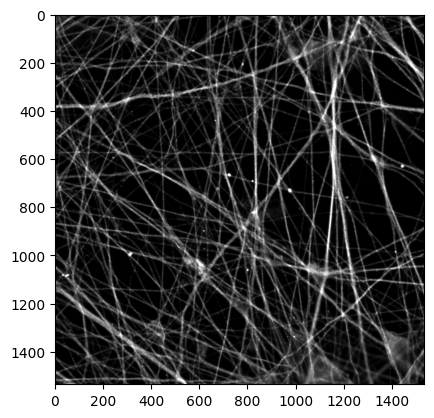

In [27]:
plt.imshow(image2d, cmap='gray')

In [28]:
with pyczi.open_czi(filepath) as czidoc:
    
    # get the raw metadata as XML
    md_xml = czidoc.raw_metadata
    print(md_xml)

<?xml version="1.0"?>
<ImageDocument>
 <Metadata>
  <DisplaySetting>
   <Channels>
    <Channel Id="Channel:0" Name="AF647-T1">
     <High>0.45695088223968705</High>
     <BitCountRange>8</BitCountRange>
     <PixelType>Gray8</PixelType>
     <DyeName>Alexa Fluor 647</DyeName>
     <IlluminationType>Fluorescence</IlluminationType>
     <DyeMaxEmission>668</DyeMaxEmission>
     <DyeMaxExcitation>653</DyeMaxExcitation>
     <DyeId>McNamara-Boswell-0057</DyeId>
     <DyeDatabaseId>66071726-cbd4-4c41-b371-0a6eee4ae9c5</DyeDatabaseId>
     <Color>#FFFF0000</Color>
     <OriginalColor>#FFFF0000</OriginalColor>
    </Channel>
    <Channel Id="Channel:1" Name="DAPI-T4">
     <IsAutoApplyEnabled>true</IsAutoApplyEnabled>
     <BitCountRange>8</BitCountRange>
     <PixelType>Gray8</PixelType>
     <DyeName>DAPI</DyeName>
     <IlluminationType>Fluorescence</IlluminationType>
     <DyeMaxEmission>465</DyeMaxEmission>
     <DyeMaxExcitation>353</DyeMaxExcitation>
     <DyeId>McNamara-Boswell-0434<

In [29]:
with pyczi.open_czi(filepath) as czidoc:

    # get the image dimensions as an dictionary, where the key identifies the dimension
    total_bounding_box = czidoc.total_bounding_box

print(total_bounding_box)

{'T': (0, 1), 'Z': (0, 3), 'C': (0, 2), 'H': (0, 1), 'X': (319836, 321372), 'Y': (153149, 154685)}


In [30]:
with pyczi.open_czi(filepath) as czidoc:

    # get the total bounding box for all scenes
    total_bounding_rectangle = czidoc.total_bounding_rectangle

print(total_bounding_rectangle)

Rectangle(x=319836, y=153149, w=1536, h=1536)


In [31]:
with pyczi.open_czi(filepath) as czidoc:
    
    # get all pixel types as a dictionary, where the key is the channel index
    pixel_type = czidoc.pixel_types

print(pixel_type)

{0: 'Gray8', 1: 'Gray8'}


Array Shape:  (1536, 1536, 1)


Text(0.5, 1.0, 'Frame_3')

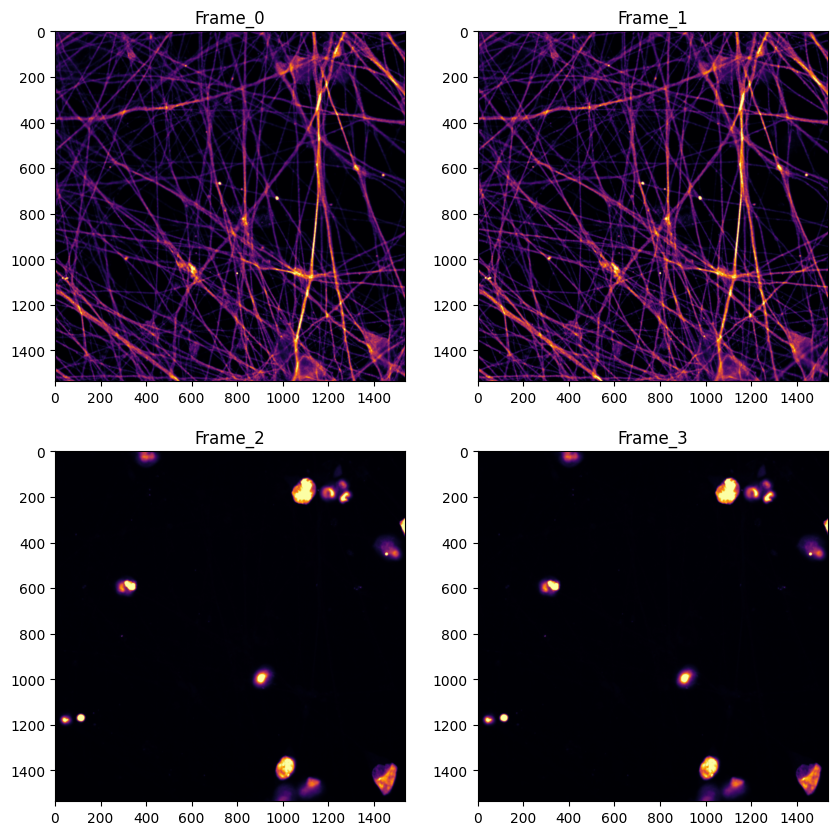

In [35]:
with pyczi.open_czi(filepath) as czidoc:

    # define some plane coordinates
    plane_1 = {'C': 0, 'Z': 1, 'T': 0}
    plane_2 = {'C': 1, 'Z': 2, 'T': 1}
    plane_3 = {'C': 1, 'Z': 2, 'T': 2}

    # equivalent to reading {'C': 0, 'Z': 0, 'T': 0}
    frame_0 = czidoc.read()

    # get the shape of the 2d plane - the last dime indicates the pixel type
    # 3 = BGR and 1 = Gray
    print("Array Shape: ", frame_0.shape)

    # get specific planes 
    frame_1 = czidoc.read(plane=plane_1)

    frame_2 = czidoc.read(plane=plane_2)

    frame_3 = czidoc.read(plane=plane_3)

fig, ax = plt.subplots(2, 2, figsize=(10, 10))
ax[0,0].imshow(frame_0[...,0], cmap=cm.inferno)
ax[0,0].set_title("Frame_0")
ax[0,1].imshow(frame_1[...,0], cmap=cm.inferno)
ax[0,1].set_title("Frame_1")
ax[1,0].imshow(frame_2[...,0], cmap=cm.inferno)
ax[1,0].set_title("Frame_2")
ax[1,1].imshow(frame_3[...,0], cmap=cm.inferno)
ax[1,1].set_title("Frame_3")